# Simulator

In [204]:
import numpy as np
import scipy as scp
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
import datetime

## Definition of System Parameters

### Cost Parameters

In [117]:
cost_failure = 1200
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30000 h$, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the parameters $\mu = 5000 h$, $\sigma = 15\% \mu$ for the time between inspections, given by a Normal distribution.

In [183]:
eta = 30000
beta = 3

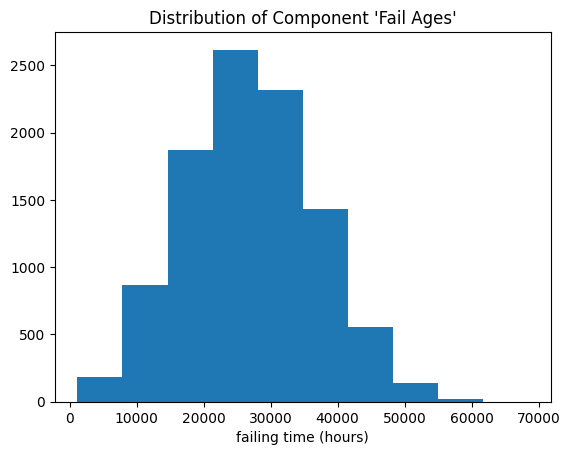

In [184]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Parameters

In [ ]:
mu = 5000
sigma = 0.15*mu

In [175]:
inspection_threshold = 0.5
inspection_deviation = 0.05 # beta: var = param * mu*(1-mu)

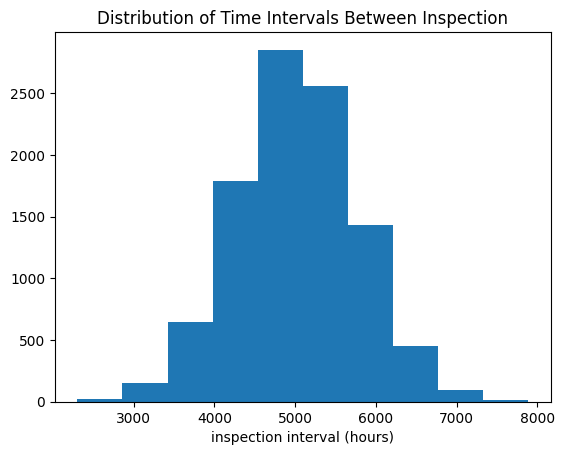

In [186]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

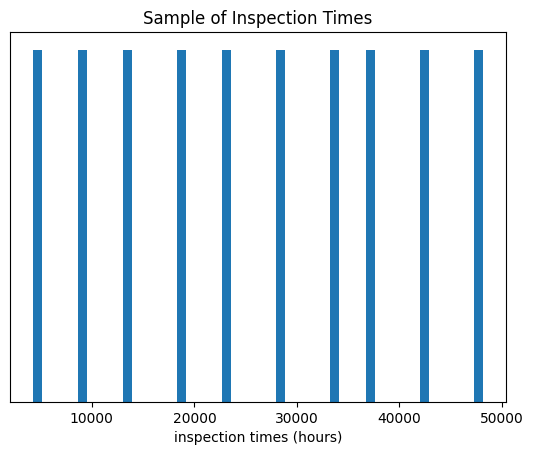

In [182]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

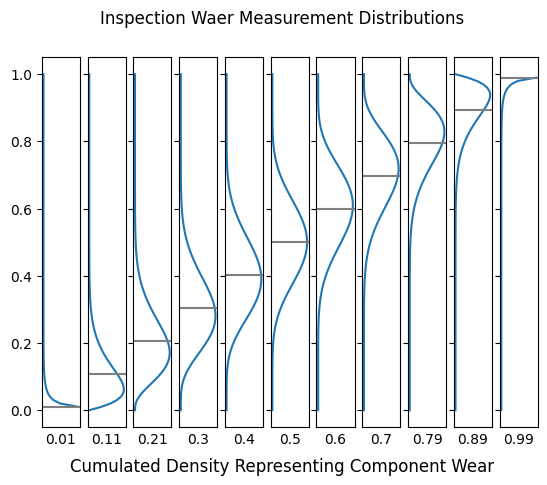

In [181]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    age_cdf = cdfs[i]

    var = inspection_deviation*age_cdf*(1-age_cdf)
    a = age_cdf * (age_cdf*(1-age_cdf)/var-1)
    b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=age_cdf, color="gray")
    ax[i].set_xlabel(age_cdf.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

## Build Simulator

We build the classes and functions responsible for describing the relevant objects (Component, System) and other relevant events, such as inspections and component replacement.

In [243]:
class Component:
    def __init__(self, id_component, eta, beta):
        self.id = id_component
        
        # distribution parameters
        self.eta = eta
        self.beta = beta

        # initial age and fail age
        self.age = 0
        self.age_fail = eta*np.random.weibull(beta)

In [284]:
class Inspector:
    def __init__(self, deviation, threshold):
        self.deviation = deviation
        self.threshold = threshold
    
    def component_cdf(self, component):
        age = component.age
        eta = component.eta
        beta = component.beta

        age_cdf = scp.stats.weibull_min.cdf(age/eta, beta)

        return age_cdf
    
    def inspect(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)

        # adds imprecision by sampling from a Beta
        var = self.deviation*age_cdf*(1-age_cdf)
        print(self.deviation, age_cdf, var)
        a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
        b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
        age_beta = np.random.beta(a,b)

        # conditional report
        replace = age_beta > self.threshold

        return replace
    
    def inspect_ff(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)
        replace = age_cdf > self.threshold

        return replace

In [300]:
class System:
    def __init__(self, id_system, component):
        self.id = id_system
        
        # age and component
        self.age = 0
        self.component = component
        
        # cummulated costs
        self.cost_cumulated = 0

    def next_event(self, curr_time, next_inspection, inspector):
        time_to_fail = self.component.age_fail-self.component.age
        time_to_inspection = next_inspection-curr_time
        time_to_event = min(time_to_inspection, time_to_fail)
        
        # update system and component age
        if time_to_event < 0:
            print(time_to_event)
        self.age += time_to_event
        self.component.age += time_to_event

        # evaluate different event cases
        ff = None

        if time_to_inspection > time_to_fail:
            event_type = "failure"
            event_cost = cost_failure
            replace_component = True
        else:
            replace = inspector.inspect(self.component)

            if replace:
                event_type = "replacement"
                event_cost = cost_replacement
                replace_component = True

                # deep inspection
                ff = inspector.inspect_ff(self.component)
            else:
                event_type = "inspection"
                event_cost = cost_inspection
                replace_component = False

        # update cost
        self.cost_cumulated += event_cost

        return time_to_event, event_type, event_cost, replace_component, ff

### System and Component Factory

Functionalities responsible for centralizing the creation of new objects with unique IDs

In [301]:
def component_factory(id_0, eta, beta):
    id_component = id_0
    while True:
        id_component += 1
        yield Component(id_component, eta, beta)

def system_factory(id_0, component_factory):
    id_system = id_0
    while True:
        id_system += 1
        component = next(component_factory)
        yield System(id_system, component)

### Simulate

In [302]:
def sample_system_dataset(system_factory, component_factory, inspector,
                          n_steps = 1000, curr_time=0, last_inspection=0):
    system_data = []

    # initialize system
    system = next(system_factory)
    for _ in range(n_steps):
        # schedule next inspection time
        next_inspection = last_inspection
        if curr_time >= last_inspection:
            next_inspection += np.random.normal(loc=mu, scale=sigma)

        # evaluate next relevant event
        event = system.next_event(curr_time, next_inspection, inspector)
        time_interval, event_type, event_cost, replace_component, ff = event

        # update time
        curr_time += time_interval
        if not event_type=="failure": 
            last_inspection = curr_time

        # update system data
        system_data.append({'system_id':system.id, 'component_id':system.component.id,
            'event_date':curr_time, 'event_type':event_type, 'system_age':system.age,
            'component_age':system.component.age, 'usage_since_last_event':time_interval,
            'FF':ff, 'cost_event':event_cost, 'cost_cumulated':system.cost_cumulated})
        
        # update system if necessary
        if replace_component:
            system.component = next(component_factory)

    system_dataframe = pd.DataFrame(system_data)

    return system_dataframe

In [303]:
c_factory = component_factory(id_0=0, eta=eta, beta=beta)
s_factory = system_factory(id_0=0, component_factory=c_factory)
inspector = Inspector(deviation=inspection_deviation, threshold=inspection_threshold)

In [306]:
df = sample_system_dataset(s_factory, c_factory, inspector, 10)

0.05 0.003934959676453868 0.0001959737884399275
0.05 0.0333447054067714 0.0016116418014053514
0.05 0.11016593933616847 0.004901470257317407
0.05 0.25425598160546525 0.009480493871165329
0.05 0.0017255405375475985 8.612815237004394e-05
0.05 0.02321864868197491 0.0011339771517678966
0.05 0.08101894392683551 0.0037227437325907894
0.05 0.00016098581976866315 8.047995166724828e-06


In [307]:
df

,system_id,component_id,event_date,event_type,system_age,component_age,usage_since_last_event,FF,cost_event,cost_cumulated
0,3,6,4739.362997,inspection,4739.362997,4739.362997,4739.362997,None,100,100
1,3,6,9710.568885,inspection,9710.568885,9710.568885,4971.205888,None,100,200
2,3,6,14661.217318,inspection,14661.217318,14661.217318,4950.648433,None,100,300
3,3,6,19934.005532,inspection,19934.005532,19934.005532,5272.788214,None,100,400
4,3,6,21309.147110,failure,21309.147110,21309.147110,1375.141579,None,1200,1600
5,3,7,24908.474066,inspection,24908.474066,3599.326956,3599.326956,None,100,1700
6,3,7,29901.207998,inspection,29901.207998,8592.060887,4992.733932,None,100,1800
7,3,7,34473.190290,inspection,34473.190290,13164.043179,4571.982292,None,100,1900
8,3,7,37005.877818,failure,37005.877818,15696.730708,2532.687529,None,1200,3100
9,3,8,38637.910241,inspection,38637.910241,1632.032423,1632.032423,None,100,3200


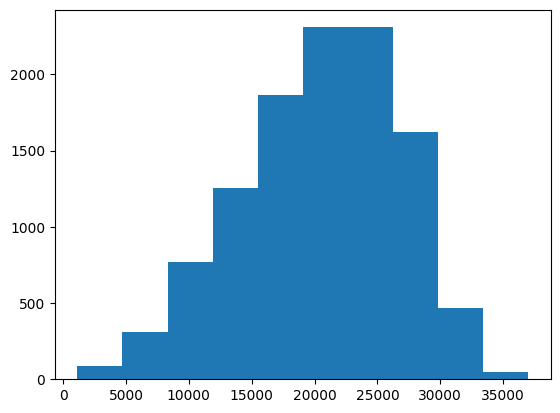

In [276]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.show()

In [201]:
datetime.datetime.fromtimestamp(3)

datetime.datetime(1970, 1, 1, 1, 0, 3)

In [ ]:
datetime.datetime.now()
# pd.to_datetime(datetime.datetime.now()).round('H')

datetime.timedelta(microseconds=1)

In [102]:
a = datetime.timedelta(hours=eta*np.random.weibull(beta))
b = datetime.timedelta(hours=eta*np.random.weibull(beta))

a,b,a+b

(datetime.timedelta(days=1356, seconds=10044, microseconds=496516),
 datetime.timedelta(days=939, seconds=13941, microseconds=693950),
 datetime.timedelta(days=2295, seconds=23986, microseconds=190466))

In [110]:
datetime.timedelta(hours=eta*np.random.weibull(beta)*100000)

datetime.timedelta(days=155020788, seconds=86106, microseconds=103706)